In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import numpy as np

In [2]:
df = pd.read_csv('./data/steam_games.csv')
df.head()

,Game Name,Price,Discount,Reviews,Tags,Release Date,Publisher
0,Counter-Strike 2,Free To Play,0%,Mostly Positive,"FPS, Shooter, Multiplayer, Competitive, Action...","Aug 21, 2012",Valve
1,Marvel Rivals,Free To Play,0%,Mixed,"Free to Play, Multiplayer, Hero Shooter, Third...","Dec 5, 2024",NetEase Games
2,Big Walk,$14.99,-25%,Very Positive,"Open World, Co-op Campaign, Puzzle, Exploratio...","Aug 4, 2026",Panic
3,HELLDIVERS™ 2,$29.99,-25%,Very Positive,"Online Co-Op, PvE, Third-Person Shooter, Multi...","Feb 8, 2024",PlayStation Publishing LLC
4,Apex Legends™,Free To Play,0%,Mixed,"Free to Play, Multiplayer, Battle Royale, FPS,...","Nov 4, 2020",Electronic Arts


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4994 entries, 0 to 4993
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Game Name     4991 non-null   str  
 1   Price         4994 non-null   str  
 2   Discount      4994 non-null   str  
 3   Reviews       4949 non-null   str  
 4   Tags          4985 non-null   str  
 5   Release Date  4986 non-null   str  
 6   Publisher     4901 non-null   str  
dtypes: str(7)
memory usage: 273.2 KB


In [4]:
df.duplicated().sum()

np.int64(139)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.isnull().sum()

Game Name        1
Price            0
Discount         0
Reviews         42
Tags             7
Release Date     6
Publisher       90
dtype: int64

In [7]:
df[df['Game Name'].isnull()]

,Game Name,Price,Discount,Reviews,Tags,Release Date,Publisher
49,NaN,Free to Play / Not Available,0%,NaN,NaN,NaN,NaN


In [8]:
df.dropna(subset=['Game Name'], inplace=True)

In [9]:
df[df['Reviews'].isnull()]

,Game Name,Price,Discount,Reviews,Tags,Release Date,Publisher
105,Call of Duty®: Modern Warfare® 4,$69.99,0%,NaN,"Action, Shooter, FPS, First-Person, PvP, Cinem...","Oct 22, 2026",Activision
106,WARDOGS,$39.99,0%,NaN,"Early Access, Action, Tactical, FPS, Multiplay...","Sep 10, 2026",Team17
109,STAR WARS Zero Company™,$49.99,0%,NaN,"Turn-Based Tactics, Turn-Based Strategy, Sci-f...","Aug 27, 2026",Electronic Arts
169,Gears of War: E-Day,$69.99,0%,NaN,"Action, Adventure, Shooter, Gore, Horror, Co-o...","Oct 6, 2026",Xbox Game Studios
187,Mortal Shell II,$49.99,0%,NaN,"Souls-like, Violent, Dark Fantasy, Action RPG,...","Aug 20, 2026",Playstack
280,EA SPORTS FC™ 27,$69.99,0%,NaN,"Sports, Football (Soccer), Multiplayer, Single...","Sep 24, 2026",Electronic Arts
297,Phantom Blade Zero,$59.99,0%,NaN,"Action RPG, Martial Arts, Action, Wuxia, Dark ...","Oct 28, 2026",S-GAME Publishing
431,NBA 2K27,$69.99,0%,NaN,"Sports, Simulation, 3D, Basketball, PvP, Chara...","Sep 3, 2026",2K
443,Halloween: The Game,$39.99,0%,NaN,"Horror, Multiplayer, Survival, Violent, Stealt...","Sep 8, 2026","IllFonic Publishing, Co-Publisher: Gun Interac..."
449,ACE COMBAT 8: WINGS OF THEVE,$69.99,0%,NaN,"Flight, Shooter, Action, Military, Vehicular C...","Oct 1, 2026",Bandai Namco Entertainment Inc.


In [10]:
df['Reviews'] = df['Reviews'].fillna('No Reviews')

In [11]:
df[df['Tags'].isnull()]

,Game Name,Price,Discount,Reviews,Tags,Release Date,Publisher
1545,Valve Index® Replacement Tether,$129.00,0%,No Reviews,NaN,NaN,NaN
2090,Valve Index® Controllers,$279.00,0%,No Reviews,NaN,NaN,NaN
2224,Valve Index® Headset,$499.00,0%,No Reviews,NaN,NaN,NaN
2283,Dead as Disco Streamer Safe Soundtrack Vol. 1,$7.99,-20%,Positive,NaN,"May 5, 2026","Brain Jar Games, Inc."
4120,Denshattack! Soundtrack,$29.01,0%,Very Positive,NaN,"Jul 15, 2026","Fireshine Games, Kid Katana Records"
4553,Root Soundtrack,$51.68,0%,Mixed,NaN,"Apr 28, 2021",Dire Wolf


In [12]:
df['Tags'] = df['Tags'].fillna('No Tags')

In [13]:
df[df['Release Date'].isnull()]

,Game Name,Price,Discount,Reviews,Tags,Release Date,Publisher
1501,Assassin’s Creed® IV Black Flag™,$300.89,-42%,Mostly Positive,"Pirates, Open World, Assassins, Adventure, Act...",NaN,Ubisoft
1539,3DMark,$32.98,0%,Overwhelmingly Positive,"Benchmark, Utilities, Software, 3D, FPS, Multi...",NaN,UL Solutions
1545,Valve Index® Replacement Tether,$129.00,0%,No Reviews,No Tags,NaN,NaN
2090,Valve Index® Controllers,$279.00,0%,No Reviews,No Tags,NaN,NaN
2224,Valve Index® Headset,$499.00,0%,No Reviews,No Tags,NaN,NaN


In [14]:
df['Release Date'] = df['Release Date'].fillna('Unknown')

In [15]:
df[df['Publisher'].isnull()]

,Game Name,Price,Discount,Reviews,Tags,Release Date,Publisher
233,Grim Dawn - Fangs of Asterkarn,$124.70,0%,Mostly Positive,"Action RPG, Hack and Slash, Loot, Isometric, D...","Jul 23, 2026",NaN
285,Escape from Tarkov - The Unheard Steam Edition...,$184.98,0%,Very Positive,"Psychological Horror, Extraction Shooter, Gun ...","May 20, 2026",NaN
392,The Binding of Isaac: Afterbirth,$35.97,0%,Very Positive,"Action Roguelike, Replay Value, Difficult, Ind...","Oct 30, 2015",NaN
505,Dead by Daylight: Jason,$22.48,0%,Mostly Positive,"Horror, Multiplayer, Survival Horror, Gore, On...","Jun 16, 2026",NaN
657,The Bazaar - The Dragons,$19.99,0%,Mixed,"Strategy, Auto Battler, Deckbuilding, Card Bat...","Aug 5, 2026",NaN
...,...,...,...,...,...,...,...
4785,Automobilista 2 - Historical Track Pack Pt4,$236.96,0%,Positive,"Action, Indie, Simulation, Racing, Sports","Jun 15, 2026",NaN
4786,of the Devil - Episode 2,$16.98,0%,Very Positive,"Dialogue Heavy, Visual Novel, Female Protagoni...","Dec 23, 2025",NaN
4820,of the Devil - Episode 1,$16.98,0%,Very Positive,"Visual Novel, Female Protagonist, Noir, Comic ...","Feb 6, 2025",NaN
4881,Teardown: Folkrace,$49.55,0%,Mixed,"Simulation, Action, Indie, Strategy, Racing","Jun 19, 2024",NaN


In [16]:
df['Publisher'] = df['Publisher'].fillna('Unknown Publisher')

In [17]:
def get_top_five_tags(tag_series):
    top_five_tags = tag_series.str.split(',').str[:5].apply(lambda x: ', '.join([tag.strip() for tag in x]))
    return top_five_tags

In [18]:
df['Top Five Tags'] = get_top_five_tags(df['Tags'])

In [19]:
df['Release Date'] = pd.to_datetime(df['Release Date'], format='mixed', errors='coerce')

In [20]:
def extract_and_convert_price(price_str):
    """
    Cleans a price string (removes '$') and converts it to a float.
    Converts 'Free To Play' to 0.0.
    """
    if isinstance(price_str, str):
        # 1. Handle the non-numeric case
        if 'Free To Play' in price_str:
            return 0.0

        # 2. Handle the currency string case
        # Remove the '$' and then attempt conversion
        cleaned_str = price_str.replace('$', '')
        try:
            return float(cleaned_str)
        except ValueError:
            # Handle unexpected formats safely
            return np.nan

    # Handle non-string inputs (like existing NaNs)
    return np.nan

In [21]:
df['Price'].unique()

<StringArray>
['Free To Play',       '$14.99',       '$29.99',       '$80.98',
       '$53.98',       '$22.48',       '$74.65',       '$59.99',
       '$81.99',       '$69.99',
 ...
       '$47.67',       '$39.16',       '$24.47',       '$24.40',
       '$36.52',       '$10.74',       '$11.91',      '$150.18',
       '$25.63',       '$52.32']
Length: 1169, dtype: str

In [24]:
df['Numeric_Price'] = df['Price'].apply(extract_and_convert_price)

In [28]:
def extract_review_count(review_str):
    """Extracts the number of reviews if present, otherwise returns 0."""
    if pd.isna(review_str):
        return 0

    # Regex looks for one or more digits (\d+) followed by any characters (.*)
    match = re.search(r'(\d+)\s+user\s+reviews', str(review_str), re.IGNORECASE)

    if match:
        # Return the captured number as an integer
        return int(match.group(1))
    else:
        # Handles 'No Reviews' or any other non-count string
        return 0

In [30]:
df['Review_Count'] = df['Reviews'].apply(extract_review_count)

In [34]:
sentiment_map = {
    'Overwhelmingly Positive': 3,
    'Very Positive': 2,
    'Positive': 1,
    'Mixed': 0,        # Neutral
    'Mostly Negative': -1,
    'Very Negative': -2,
    'Overwhelmingly Negative': -3,
    # 'No Reviews' strings should default to 0 or NaN, we handle this below
}

def encode_sentiment(review_str):
    """Converts sentiment string to a numerical score based on defined mapping."""
    if pd.isna(review_str) or 'No' in review_str:
        return 0 # Neutral score if count is zero or not defined

    # Find the best match from our map
    for sentiment, score in sentiment_map.items():
        if sentiment in review_str:
            return score

    return 0 # Default to neutral if no match is found

# Create the second new column for the sentiment score
df['Sentiment_Score'] = df['Reviews'].apply(encode_sentiment)

In [39]:
print(df.head())

          Game Name         Price Discount          Reviews  \
0  Counter-Strike 2  Free To Play       0%  Mostly Positive   
1     Marvel Rivals  Free To Play       0%            Mixed   
2          Big Walk        $14.99     -25%    Very Positive   
3     HELLDIVERS™ 2        $29.99     -25%    Very Positive   
4     Apex Legends™  Free To Play       0%            Mixed   

                                                Tags Release Date  \
0  FPS, Shooter, Multiplayer, Competitive, Action...   2012-08-21   
1  Free to Play, Multiplayer, Hero Shooter, Third...   2024-12-05   
2  Open World, Co-op Campaign, Puzzle, Exploratio...   2026-08-04   
3  Online Co-Op, PvE, Third-Person Shooter, Multi...   2024-02-08   
4  Free to Play, Multiplayer, Battle Royale, FPS,...   2020-11-04   

                    Publisher  \
0                       Valve   
1               NetEase Games   
2                       Panic   
3  PlayStation Publishing LLC   
4             Electronic Arts   

       

# Visualizations

In [40]:
# Set a consistent style for better visual appeal
sns.set_theme(style="whitegrid")

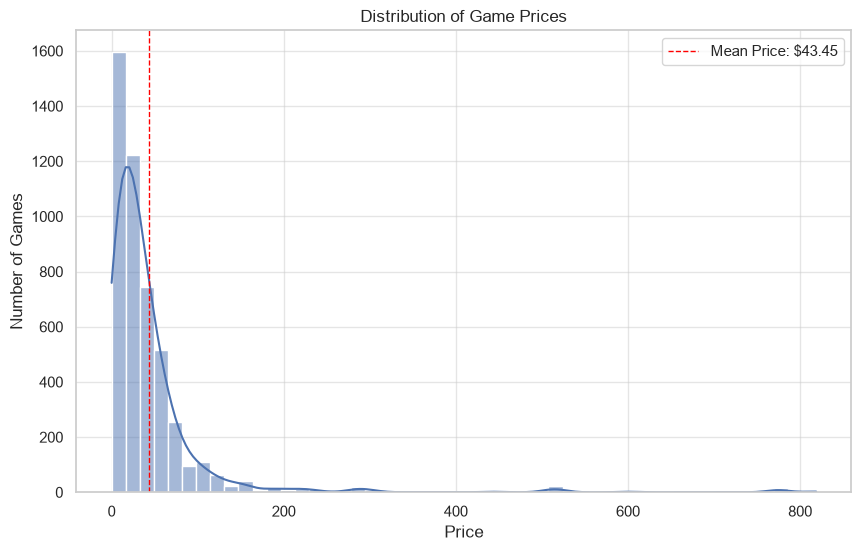

In [41]:
# --- Visualization 1: Price Distribution (What is the typical price?) ---
plt.figure(figsize=(10, 6))
# Use a histogram to see where most of your prices fall
sns.histplot(df['Numeric_Price'], bins=50, kde=True)
plt.title('Distribution of Game Prices')
plt.xlabel('Price')
plt.ylabel('Number of Games')
plt.axvline(df['Numeric_Price'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean Price: ${df["Numeric_Price"].mean():.2f}')
plt.legend()
plt.show()

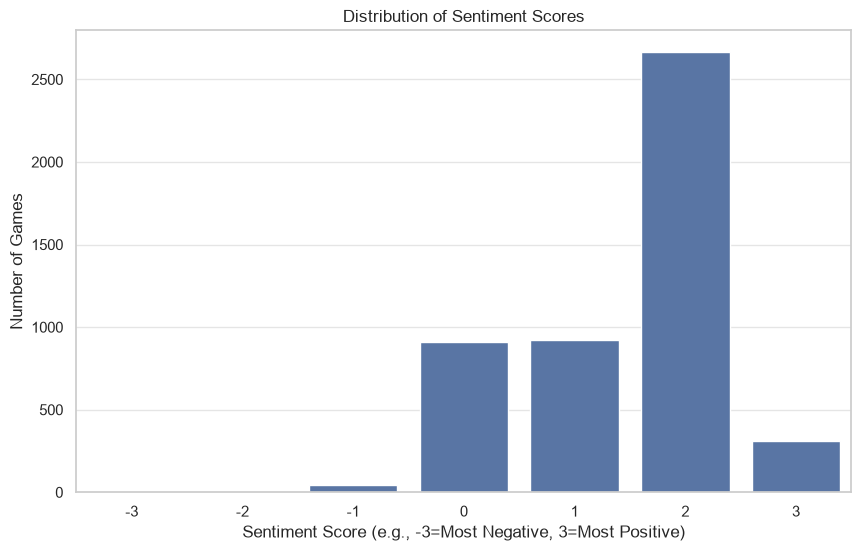

In [42]:
# --- Visualization 2: Sentiment Distribution (How are the games rated overall?) ---
plt.figure(figsize=(10, 6))
# Count how many games fall into each sentiment score
sns.countplot(x='Sentiment_Score', data=df)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score (e.g., -3=Most Negative, 3=Most Positive)')
plt.ylabel('Number of Games')
plt.show()

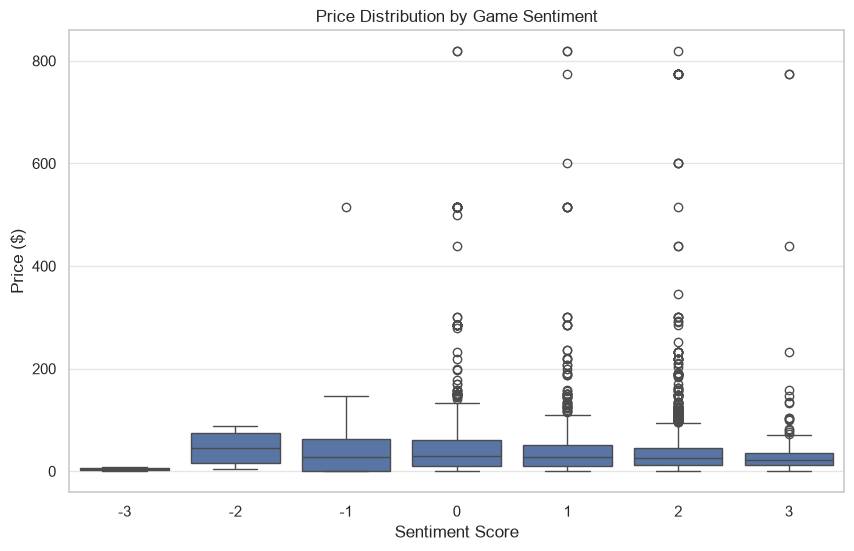

In [44]:
# --- Visualization 3: Relationship between Price and Sentiment (Do good games cost more?) ---
plt.figure(figsize=(10, 6))
# Box plots show the spread of prices for each sentiment group
sns.boxplot(x='Sentiment_Score', y='Numeric_Price', data=df)
plt.title('Price Distribution by Game Sentiment')
plt.xlabel('Sentiment Score')
plt.ylabel('Price ($)')
plt.show()

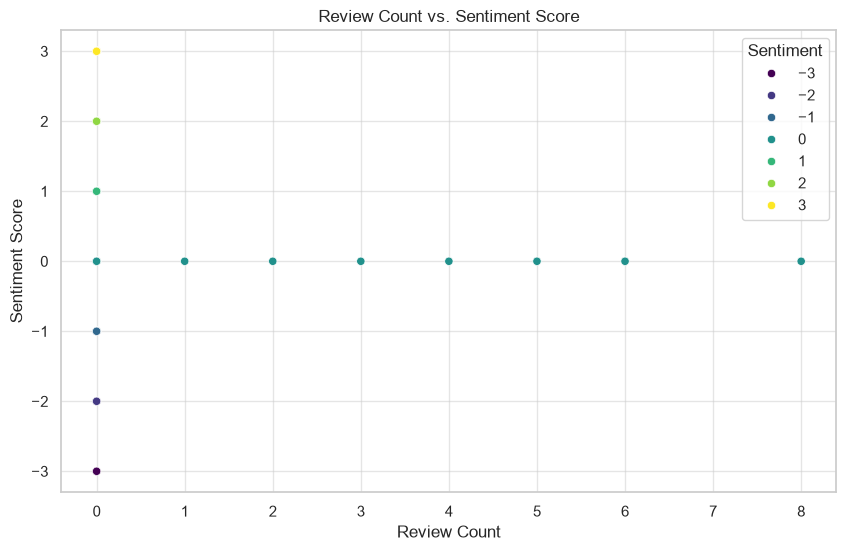

In [45]:
# --- Visualization 4: Review Count vs. Sentiment (Does popularity predict rating?) ---
plt.figure(figsize=(10, 6))
# Scatter plot shows if games with more reviews tend to have a specific rating
sns.scatterplot(x='Review_Count', y='Sentiment_Score', data=df, hue='Sentiment_Score', palette='viridis')
plt.title('Review Count vs. Sentiment Score')
plt.xlabel('Review Count')
plt.ylabel('Sentiment Score')
plt.legend(title='Sentiment')
plt.show()

C:\Users\ahsan\AppData\Local\Temp\ipykernel_2776\127901405.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_counts.index, y=publisher_counts.values, palette='viridis')


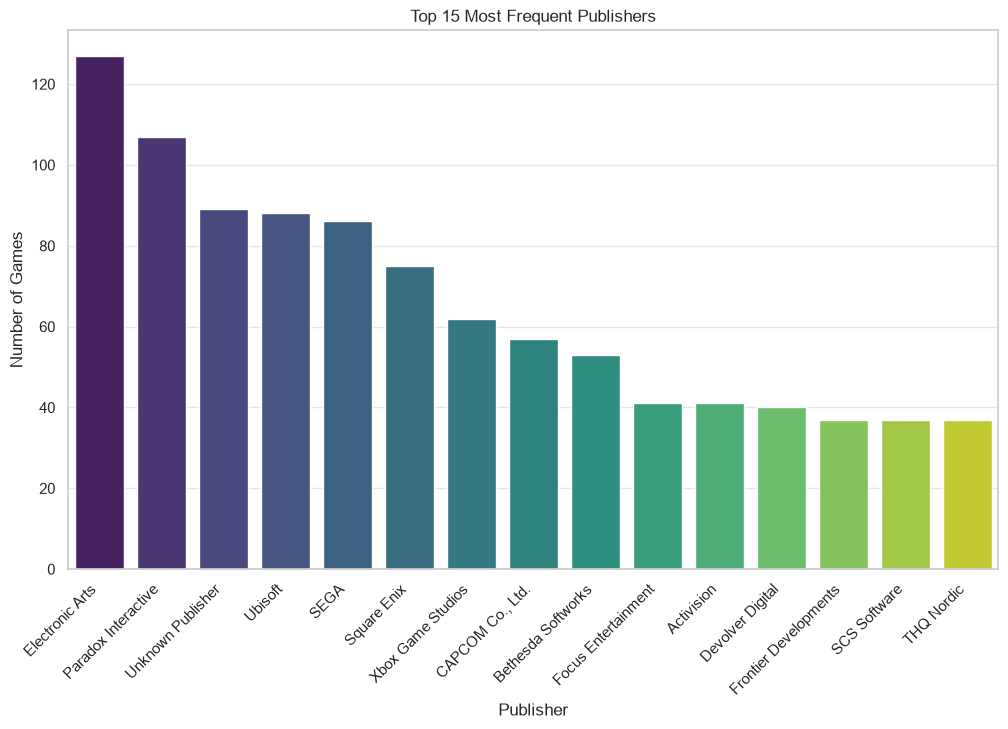

In [46]:
# --- Visualization 5: Top Publishers (Who is in the market?) ---
plt.figure(figsize=(12, 7))
# Count how many games each publisher has
publisher_counts = df['Publisher'].value_counts().head(15) # Show top 15
sns.barplot(x=publisher_counts.index, y=publisher_counts.values, palette='viridis')
plt.title('Top 15 Most Frequent Publishers')
plt.xlabel('Publisher')
plt.ylabel('Number of Games')
plt.xticks(rotation=45, ha='right') # Rotate names so they don't overlap
plt.show()

C:\Users\ahsan\AppData\Local\Temp\ipykernel_2776\3966305306.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tag_counts.index, y=tag_counts.values, palette='coolwarm')


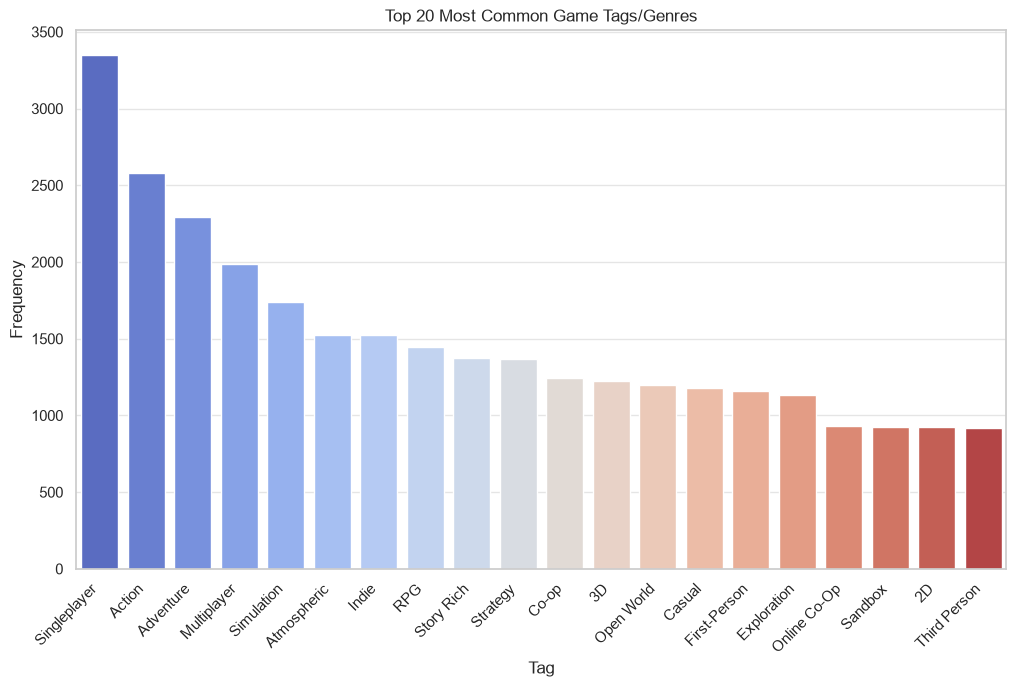

In [47]:
# --- Visualization 6: Tag Popularity (What genres are most common?) ---
# Note: This assumes the 'Tags' column is a comma-separated string.
from collections import Counter

def tag_extractor(tags):
    """Extracts and splits tags from a string."""
    if pd.isna(tags):
        return []
    # Split by comma and strip whitespace
    return [tag.strip() for tag in tags.split(',')]

# Apply the extractor to get a list of all tags
all_tags = df['Tags'].apply(tag_extractor).explode()

# Count the frequency of each tag
tag_counts = all_tags.value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=tag_counts.index, y=tag_counts.values, palette='coolwarm')
plt.title('Top 20 Most Common Game Tags/Genres')
plt.xlabel('Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()